In [210]:
import numpy as np
import scipy.linalg
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import time
np.set_printoptions(precision=3)
from qutip import Qobj 

In [211]:
gstate = np.array([1,0,0], dtype = complex)
estate = np.array([0,1,0], dtype = complex)
rstate = np.array([0,0,1], dtype = complex)

a=1
b=0
c=0
Omega = 2
Gamma = 1
Gamma_r = 0.3

psi0 = a*gstate + b*estate + c*rstate

rho0 = np.kron(psi0, psi0.conj())

sigma_ge_mat = np.array([[0,1,0], [0,0,0], [0,0,0]], dtype = complex)
sigma_gr_mat = np.array([[0,0,1], [0,0,0], [0,0,0]], dtype = complex)
sigma_er_mat = np.array([[0,0,0], [0,0,1], [0,0,0]], dtype = complex)
sigma_ge_mat_deg = np.array([[0,0,0], [1,0,0], [0,0,0]], dtype = complex)
sigma_gr_mat_deg = np.array([[0,0,0], [0,0,0], [1,0,0]], dtype = complex)
sigma_er_mat_deg = np.array([[0,0,0], [0,0,0], [0,1,0]], dtype = complex)
Id3 = np.identity(3)

sigma_ge_left = np.kron(sigma_ge_mat, Id3)
sigma_ge_right = np.kron(Id3, sigma_ge_mat.T)
sigma_ge_left_deg = np.kron(sigma_ge_mat_deg, Id3)
sigma_ge_right_deg = np.kron(Id3, sigma_ge_mat_deg.T)

sigma_gr_left = np.kron(sigma_gr_mat, Id3)
sigma_gr_right = np.kron(Id3, sigma_gr_mat.T)
sigma_gr_left_deg = np.kron(sigma_gr_mat_deg, Id3)
sigma_gr_right_deg = np.kron(Id3, sigma_gr_mat_deg.T)


sigma_er_left = np.kron(sigma_er_mat, Id3)
sigma_er_right = np.kron(Id3, sigma_er_mat.T)
sigma_er_left_deg = np.kron(sigma_er_mat_deg, Id3)
sigma_er_right_deg = np.kron(Id3, sigma_er_mat_deg.T)

#print(sigma_gr_right_deg, sigma_ge_right_deg)

#sigx = np.array([[0,1], [1,0]])
#sigz = np.array([[1,0], [0,-1]])
#y = comm(sigx, sigx)


In [212]:
H_mat = Omega*0.5*(sigma_gr_mat+sigma_gr_mat_deg)
H_left = np.kron(H_mat, Id3)
H_right = np.kron(Id3, H_mat.T)

def D_op(rho, c_mat, c_left, c_left_deg, c_right, c_right_deg):
    def c_rho_cdeg(rho1, c_mat1):
        A = c_mat1
        B = c_mat1.conj().T
        return np.kron(A, B.T)@rho1
    
    S1 = 2*c_rho_cdeg(rho, c_mat)

    def cdeg_c_rho(rho2, c_left2, c_left_deg2):
        step1 = c_left2 @ rho2
        return c_left_deg2 @ step1
    S2 = -cdeg_c_rho(rho, c_left, c_left_deg)

    def rho_cdeg_c(rho3, c_right3, c_right_deg3):
        step1_3 = c_right_deg3 @ rho3
        return c_right3 @ step1_3
    S3 = -rho_cdeg_c(rho, c_right, c_right_deg)
    return S1 + S2 + S3

def commutator_term(rho, O_left, O_right):
    return -1j*((O_left@rho) - O_right@rho)

def Liouville(t,rho):
    T1 = commutator_term(rho, H_left, H_right)
    T2 = Gamma* 0.5 * D_op(rho, sigma_ge_mat, sigma_ge_left, sigma_ge_left_deg, sigma_ge_right, sigma_ge_right_deg)
    T3 = Gamma_r * 0.5 * D_op(rho, sigma_er_mat, sigma_er_left, sigma_er_left_deg, sigma_er_right, sigma_er_right_deg)
    return T1 + T2 + T3
#print(Liouville(1,rho0))

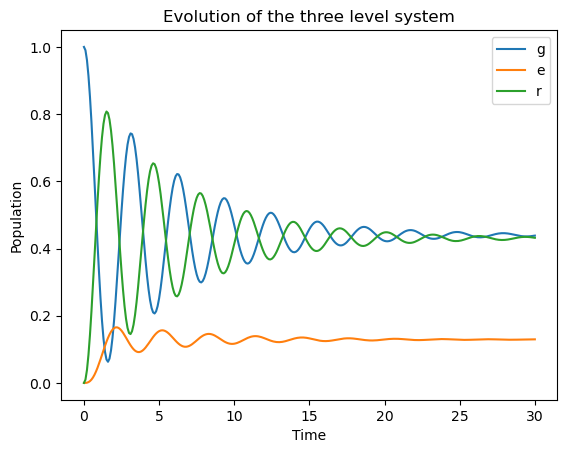

In [213]:
tsteps= 301
t_span = np.linspace(0,30,tsteps)  
sol=solve_ivp(Liouville,(t_span[0],t_span[-1]),rho0,t_eval=t_span) 
rho_t=sol.y
plt.plot(t_span, np.real(rho_t[0]), label='g')
plt.plot(t_span, np.real(rho_t[4]), label='e')
plt.plot(t_span, np.real(rho_t[8]), label='r')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title("Evolution of the three level system")
plt.legend()
plt.show()

#plt.plot(t_span, rho_t[0])
#plt.plot(t_span, rho_t[4])
#plt.plot(t_span, rho_t[8])


#Idee how to fix: ich hab glaub die dgl flasch aufgesetzt und da rho0 anstatt rho eingesetzt und deswegen ist meine time evolution cursesd.nochmal neu machen aber in korrigiert

One can see that there are oscillations between the r and g state while the state also decays through the e state.

# b)

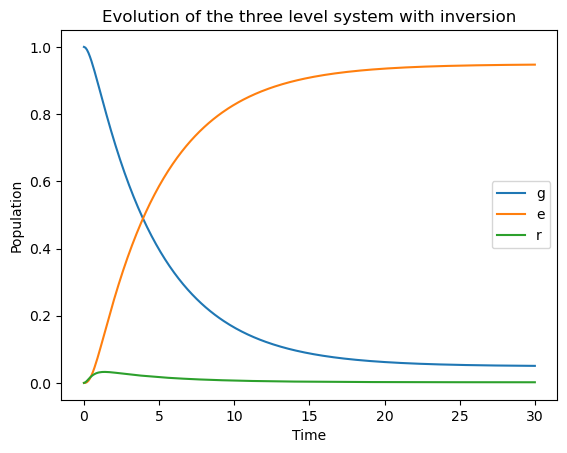

In [216]:
gstate = np.array([1,0,0], dtype = complex)
estate = np.array([0,1,0], dtype = complex)
rstate = np.array([0,0,1], dtype = complex)

a=1
b=0
c=0
Omega = 1
Gamma = 0.01
Gamma_r = 5

psi0 = a*gstate + b*estate + c*rstate

rho0 = np.kron(psi0, psi0.conj())

sigma_ge_mat = np.array([[0,1,0], [0,0,0], [0,0,0]], dtype = complex)
sigma_gr_mat = np.array([[0,0,1], [0,0,0], [0,0,0]], dtype = complex)
sigma_er_mat = np.array([[0,0,0], [0,0,1], [0,0,0]], dtype = complex)
sigma_ge_mat_deg = np.array([[0,0,0], [1,0,0], [0,0,0]], dtype = complex)
sigma_gr_mat_deg = np.array([[0,0,0], [0,0,0], [1,0,0]], dtype = complex)
sigma_er_mat_deg = np.array([[0,0,0], [0,0,0], [0,1,0]], dtype = complex)
Id3 = np.identity(3)

sigma_ge_left = np.kron(sigma_ge_mat, Id3)
sigma_ge_right = np.kron(Id3, sigma_ge_mat.T)
sigma_ge_left_deg = np.kron(sigma_ge_mat_deg, Id3)
sigma_ge_right_deg = np.kron(Id3, sigma_ge_mat_deg.T)

sigma_gr_left = np.kron(sigma_gr_mat, Id3)
sigma_gr_right = np.kron(Id3, sigma_gr_mat.T)
sigma_gr_left_deg = np.kron(sigma_gr_mat_deg, Id3)
sigma_gr_right_deg = np.kron(Id3, sigma_gr_mat_deg.T)


sigma_er_left = np.kron(sigma_er_mat, Id3)
sigma_er_right = np.kron(Id3, sigma_er_mat.T)
sigma_er_left_deg = np.kron(sigma_er_mat_deg, Id3)
sigma_er_right_deg = np.kron(Id3, sigma_er_mat_deg.T)

H_mat = Omega*0.5*(sigma_gr_mat+sigma_gr_mat_deg)
H_left = np.kron(H_mat, Id3)
H_right = np.kron(Id3, H_mat.T)

def D_op(rho, c_mat, c_left, c_left_deg, c_right, c_right_deg):
    def c_rho_cdeg(rho1, c_mat1):
        A = c_mat1
        B = c_mat1.conj().T
        return np.kron(A, B.T)@rho1
    
    S1 = 2*c_rho_cdeg(rho, c_mat)

    def cdeg_c_rho(rho2, c_left2, c_left_deg2):
        step1 = c_left2 @ rho2
        return c_left_deg2 @ step1
    S2 = -cdeg_c_rho(rho, c_left, c_left_deg)

    def rho_cdeg_c(rho3, c_right3, c_right_deg3):
        step1_3 = c_right_deg3 @ rho3
        return c_right3 @ step1_3
    S3 = -rho_cdeg_c(rho, c_right, c_right_deg)
    return S1 + S2 + S3

def commutator_term(rho, O_left, O_right):
    return -1j*((O_left@rho) - O_right@rho)

def Liouville(t,rho):
    T1 = commutator_term(rho, H_left, H_right)
    T2 = Gamma* 0.5 * D_op(rho, sigma_ge_mat, sigma_ge_left, sigma_ge_left_deg, sigma_ge_right, sigma_ge_right_deg)
    T3 = Gamma_r * 0.5 * D_op(rho, sigma_er_mat, sigma_er_left, sigma_er_left_deg, sigma_er_right, sigma_er_right_deg)
    return T1 + T2 + T3

tsteps= 301
t_span = np.linspace(0,30,tsteps)  
sol=solve_ivp(Liouville,(t_span[0],t_span[-1]),rho0,t_eval=t_span) 
rho_t=sol.y
plt.plot(t_span, np.real(rho_t[0]), label='g')
plt.plot(t_span, np.real(rho_t[4]), label='e')
plt.plot(t_span, np.real(rho_t[8]), label='r')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title("Evolution of the three level system with inversion")
plt.legend()
plt.show()

As we can see, for small Gammas and relatively big gamma_r, we get a population inversion

/opt/anaconda3/envs/Qutip_E/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/Qutip_E/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


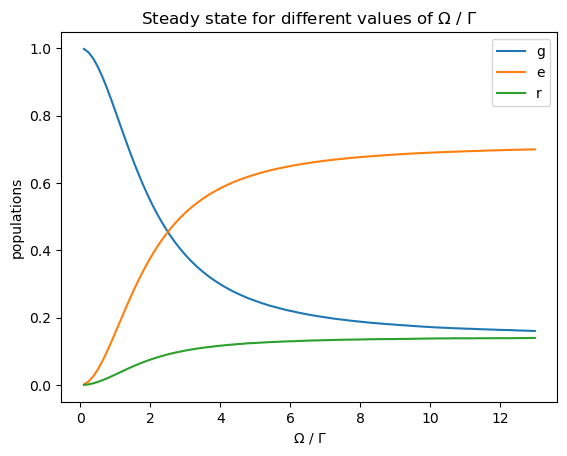

In [226]:
def steadystate(R):
    gstate = np.array([1,0,0], dtype = complex)
    estate = np.array([0,1,0], dtype = complex)
    rstate = np.array([0,0,1], dtype = complex)

    a=1
    b=0
    c=0
    Omega = 1
    Gamma = Omega/R
    Gamma_r = Gamma*5
    
    
    

    si0 = a*gstate + b*estate + c*rstate

    rho0 = np.kron(psi0, psi0.conj())

    sigma_ge_mat = np.array([[0,1,0], [0,0,0], [0,0,0]], dtype = complex)
    sigma_gr_mat = np.array([[0,0,1], [0,0,0], [0,0,0]], dtype = complex)
    sigma_er_mat = np.array([[0,0,0], [0,0,1], [0,0,0]], dtype = complex)
    sigma_ge_mat_deg = np.array([[0,0,0], [1,0,0], [0,0,0]], dtype = complex)
    sigma_gr_mat_deg = np.array([[0,0,0], [0,0,0], [1,0,0]], dtype = complex)
    sigma_er_mat_deg = np.array([[0,0,0], [0,0,0], [0,1,0]], dtype = complex)
    Id3 = np.identity(3)

    igma_ge_left = np.kron(sigma_ge_mat, Id3)
    sigma_ge_right = np.kron(Id3, sigma_ge_mat.T)
    sigma_ge_left_deg = np.kron(sigma_ge_mat_deg, Id3)
    sigma_ge_right_deg = np.kron(Id3, sigma_ge_mat_deg.T)

    sigma_gr_left = np.kron(sigma_gr_mat, Id3)
    sigma_gr_right = np.kron(Id3, sigma_gr_mat.T)
    sigma_gr_left_deg = np.kron(sigma_gr_mat_deg, Id3)
    sigma_gr_right_deg = np.kron(Id3, sigma_gr_mat_deg.T)


    sigma_er_left = np.kron(sigma_er_mat, Id3)
    sigma_er_right = np.kron(Id3, sigma_er_mat.T)
    sigma_er_left_deg = np.kron(sigma_er_mat_deg, Id3)
    sigma_er_right_deg = np.kron(Id3, sigma_er_mat_deg.T)

    H_mat = Omega*0.5*(sigma_gr_mat+sigma_gr_mat_deg)
    H_left = np.kron(H_mat, Id3)
    H_right = np.kron(Id3, H_mat.T)

    def D_op(rho, c_mat, c_left, c_left_deg, c_right, c_right_deg):
        def c_rho_cdeg(rho1, c_mat1):
            A = c_mat1
            B = c_mat1.conj().T
            return np.kron(A, B.T)@rho1
    
        S1 = 2*c_rho_cdeg(rho, c_mat)

        def cdeg_c_rho(rho2, c_left2, c_left_deg2):
            step1 = c_left2 @ rho2
            return c_left_deg2 @ step1
        S2 = -cdeg_c_rho(rho, c_left, c_left_deg)

        def rho_cdeg_c(rho3, c_right3, c_right_deg3):
            step1_3 = c_right_deg3 @ rho3
            return c_right3 @ step1_3
        S3 = -rho_cdeg_c(rho, c_right, c_right_deg)
        return S1 + S2 + S3

    def commutator_term(rho, O_left, O_right):
        return -1j*((O_left@rho) - O_right@rho)

    def Liouville(t,rho):
        T1 = commutator_term(rho, H_left, H_right)
        T2 = Gamma* 0.5 * D_op(rho, sigma_ge_mat, sigma_ge_left, sigma_ge_left_deg, sigma_ge_right, sigma_ge_right_deg)
        T3 = Gamma_r * 0.5 * D_op(rho, sigma_er_mat, sigma_er_left, sigma_er_left_deg, sigma_er_right, sigma_er_right_deg)
        return T1 + T2 + T3
    tsteps= 100
    t_span = np.linspace(0,100,tsteps)  
    sol=solve_ivp(Liouville,(t_span[0],t_span[-1]),rho0,t_eval=t_span) 
    rho_t=sol.y
    p_g, p_e, p_r = rho_t[0][-1], rho_t[4][-1], rho_t[8][-1]
    return p_g, p_e, p_r

r_vals = np.linspace(0.1, 13, 100)
steady0 = []
steady1 = []
steady2 = []
for i in r_vals:
    steady0.append(steadystate(i)[0])
    steady1.append(steadystate(i)[1])
    steady2.append(steadystate(i)[2])

plt.plot(r_vals, steady0, label="g")
plt.plot(r_vals, steady1, label="e")
plt.plot(r_vals, steady2, label="r")
plt.ylabel("populations")
plt.xlabel(r"$\Omega$ / $\Gamma$")
plt.title(r"Steady state for different values of $\Omega$ / $\Gamma$")
plt.legend()

As we can see, for small values of Omega/Gamma (i.e. for big decay rates compared to Omega), we end up with most of the population in the ground state, which is reasonable. If the decay rate Gamma grows, the transfer to the e-level grows amd we end up with a bigger part of the population being in the e state